In [49]:
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import (KFold, LeaveOneOut,
                                     RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_score, train_test_split)

from pandas.api.types import CategoricalDtype
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import (GridSearchCV, cross_validate,
                                     train_test_split)
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             mean_absolute_error, mean_squared_error,
                             median_absolute_error, r2_score)
from sklearn.model_selection import (GridSearchCV, cross_validate,
                                     train_test_split)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR, LinearSVR

warnings.filterwarnings('ignore')

pd.set_option('display.precision', 6)
np.set_printoptions(precision=6)

In [95]:
X_train_full = pd.read_csv('../data/processed/train_nt_mar_proc.csv')
X_test = pd.read_csv('../data/processed/test_nt_mar_proc.csv')
y_train_full = pd.read_csv('../data/processed/y_train_nt_mar_proc.csv')
y_train_full = y_train_full.loc[X_train_full.index]
y_test = pd.read_csv('../data/processed/y_test_nt_mar_proc.csv')

X_train_full.shape, X_test.shape, y_train_full.shape, y_test.shape


X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2)

In [51]:
def display_confusion_matrix(true, pred, ax=None):
    """
    Function for pretty printing confusion matrices
    """
    disp = ConfusionMatrixDisplay.from_predictions(true, pred)
    disp.plot(ax=ax)

# LDA

In [52]:
lda = LinearDiscriminantAnalysis() 
lda.fit(X_train, y_train)
lda_val_score = accuracy_score(y_val, lda.predict(X_val))
print(f'LDA validation score: {lda_val_score}')

LDA validation score: 0.7595494613124388


In [53]:
scores = cross_val_score(lda, X_train, y_train, cv=5)
print((scores.mean()))

0.7664050290781997


0.7777346780449961


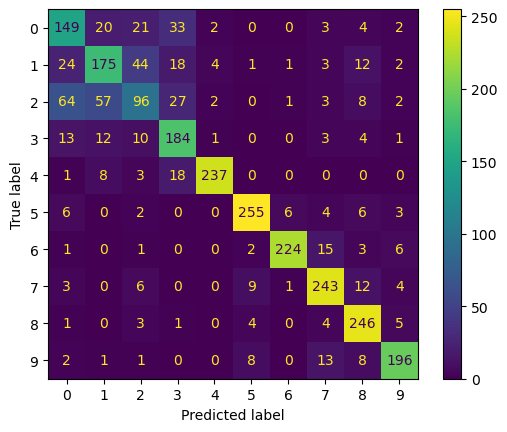

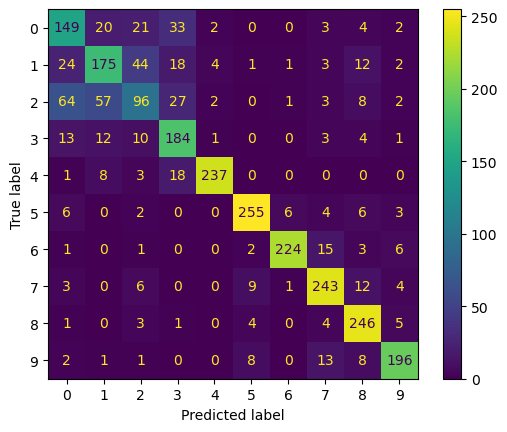

In [54]:
lda.fit(X_train_full, y_train_full)
y_pred = lda.predict(X_test)
test_score = accuracy_score(y_test, y_pred)
print(test_score)
cm = ConfusionMatrixDisplay.from_estimator(lda, X_test, y_test)
cm.plot()

In [55]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)
X_transformed = lda_model.transform(X_train)

X_transformed = pd.DataFrame(X_transformed)
X_transformed['labels'] = y_train.reset_index(drop=True)
X_transformed

,0,1,2,3,4,5,6,7,8,labels
0,-0.240436,-0.936200,-2.554200,-1.666695,-0.619274,1.029292,-0.792290,0.787248,-1.598814,1
1,-1.956560,-0.529699,0.051556,0.133477,0.807437,-0.819518,-1.921210,-0.318366,-0.499157,2
2,4.556317,5.087731,1.067441,2.628380,2.793359,-0.703591,0.890841,0.509436,0.077195,6
3,-2.011834,1.161976,-0.219226,1.037100,-0.000117,-0.414481,2.040005,-0.795427,-0.635743,2
4,4.491674,6.586183,0.580245,1.954633,2.459587,-0.004492,2.001126,-0.452408,1.326690,6
...,...,...,...,...,...,...,...,...,...,...
8163,-2.429612,0.356088,-0.127585,0.576443,-0.617240,-0.241511,1.739431,1.191988,0.086984,0
8164,-2.059373,0.805656,-0.302420,0.558982,-0.147808,0.022337,1.735242,-0.676015,-0.983803,2
8165,-1.596050,-0.001575,0.363728,-0.242465,-0.012816,-1.859932,-1.183856,-0.419972,1.662311,3
8166,3.371406,-2.412693,-2.645534,3.639716,-3.144309,0.561750,0.464436,-0.120900,-0.946075,9


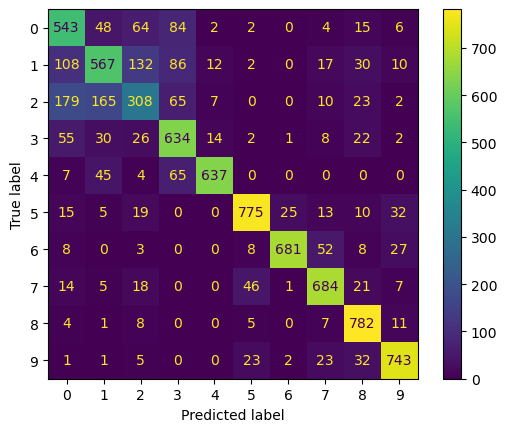

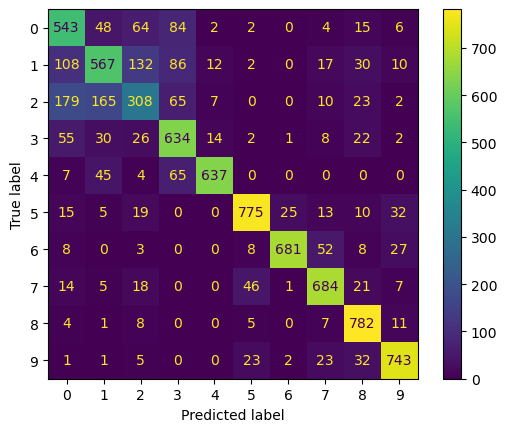

In [56]:
display_confusion_matrix(y_train, pd.Series(lda_model.predict(X_train)))  

In [57]:
results_df = pd.DataFrame(index=[], columns= ['Accuracy', 'F1 Macro', 'Precision Macro', 'Recall Macro'])
cross_val_results = pd.DataFrame(cross_validate(lda_model , X_train, y_train, cv = 5, 
                            scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'] ))

results_df.loc['LDA',:] = cross_val_results[['test_accuracy', 'test_f1_macro',
       'test_precision_macro', 'test_recall_macro']].mean().values
results_df

,Accuracy,F1 Macro,Precision Macro,Recall Macro
LDA,0.766405,0.763654,0.767966,0.766395


# QDA

In [58]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
qda_val_score = accuracy_score(y_val, qda.predict(X_val))
print(f'QDA validation score: {qda_val_score}')

QDA validation score: 0.7644466209598433


In [59]:
scores = cross_val_score(qda, X_train, y_train, cv=5)
print((scores.mean()))

0.7704471199502908


0.7668735453840186


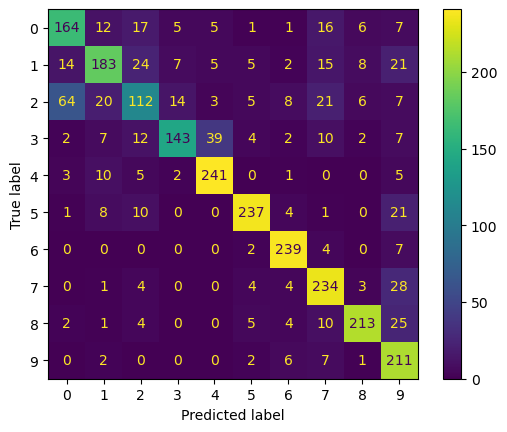

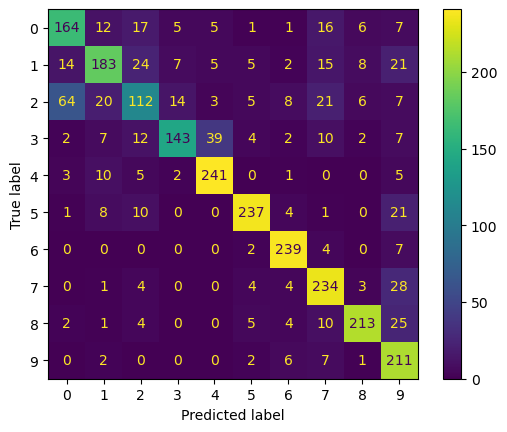

In [60]:
qda.fit(X_train_full, y_train_full)
y_pred = qda.predict(X_test)
test_score = accuracy_score(y_test, y_pred)
print(test_score)
cm = ConfusionMatrixDisplay.from_estimator(qda, X_test, y_test)
cm.plot()

In [61]:
reg_param_values = [0, 0.0001, 0.001, 0.1, 1]

results_qda_df = pd.DataFrame(index=[], columns= ['reg_param', 'Accuracy', 'F1 Macro', 'Precision Macro', 'Recall Macro'])

for i, reg_value in enumerate(reg_param_values):
    qda_model = QuadraticDiscriminantAnalysis(reg_param=reg_value)

    cross_val_results = pd.DataFrame(cross_validate(qda_model , X_train, y_train, cv = 5, scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'] ))

    results_qda_df.loc[f'{i}',:] = [reg_value] + list(cross_val_results[['test_accuracy', 'test_f1_macro',
        'test_precision_macro', 'test_recall_macro']].mean().values)

results_qda_df = results_qda_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_qda_df

,reg_param,Accuracy,F1 Macro,Precision Macro,Recall Macro
0,0,0.770447,0.763052,0.774458,0.768019
1,0.0001,0.769957,0.76224,0.773569,0.767511
2,0.001,0.769957,0.761539,0.772689,0.76795
3,0.1,0.748774,0.743632,0.770088,0.752789
4,1,0.651198,0.639331,0.646524,0.650331


In [62]:
kf = StratifiedKFold(n_splits=3, shuffle=True)

lda_val_scores = []
qda_val_scores = []

for train_index, val_index in kf.split(X_train_full, y_train_full):
    X_train = X_train_full.iloc[train_index]
    X_val = X_train_full.iloc[val_index]
    y_train = y_train_full.iloc[train_index]
    y_val = y_train_full.iloc[val_index]

    # Train LDA model and estimate performance on validation set
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train, y_train)
    lda_val_scores.append(accuracy_score(y_val, lda.predict(X_val)))

    # Train QDA model and estimate performance on validation set
    qda = QuadraticDiscriminantAnalysis()
    qda.fit(X_train, y_train)
    qda_val_scores.append(accuracy_score(y_val, qda.predict(X_val)))

# Average accuracy across all folds
lda_val_scores = np.mean(lda_val_scores)
qda_val_scores = np.mean(qda_val_scores)

# Select winner
print(f'LDA has score {lda_val_scores:.2f}')
print(f'QDA has score {qda_val_scores:.2f}')
if lda_val_scores > qda_val_scores:
    print(f'So, LDA wins.')
    winner = lda
else:
    print(f'So, QDA wins.')
    winner = qda

LDA has score 0.77
QDA has score 0.77
So, QDA wins.


# KNN

In [63]:
knn = KNeighborsClassifier()

knn_cv = GridSearchCV(
    estimator=knn,
    param_grid={
        'n_neighbors': [1, 3, 5, 7, 10, 15, 20],
        'metric': ['euclidean', 'minkowski', 'manhattan']
    },
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit=False
)

knn_cv.fit(X_train, y_train)
results_knn_df = pd.DataFrame(knn_cv.cv_results_)

In [64]:
cols = ['param_n_neighbors', 'param_metric',
     'mean_test_accuracy',
    'mean_test_f1_macro', 'mean_test_precision_macro',
    'mean_test_recall_macro', 
    'std_test_accuracy', 'std_test_f1_macro', 'std_test_precision_macro',
    'std_test_recall_macro'
]
results_knn_df = results_knn_df[cols].sort_values(by='mean_test_accuracy',ascending=False).reset_index(drop=True)
results_knn_df

,param_n_neighbors,param_metric,mean_test_accuracy,mean_test_f1_macro,mean_test_precision_macro,mean_test_recall_macro,std_test_accuracy,std_test_f1_macro,std_test_precision_macro,std_test_recall_macro
0,1,manhattan,0.830615,0.833295,0.841235,0.832003,0.008736,0.008319,0.007355,0.008548
1,1,minkowski,0.826502,0.830298,0.838508,0.828196,0.008381,0.007852,0.006983,0.008659
2,1,euclidean,0.826502,0.830298,0.838508,0.828196,0.008381,0.007852,0.006983,0.008659
3,3,manhattan,0.813427,0.818473,0.835003,0.814581,0.010161,0.009399,0.008341,0.010143
4,5,manhattan,0.810194,0.814540,0.829559,0.811351,0.008412,0.007588,0.005405,0.008417
5,5,minkowski,0.806962,0.812371,0.828198,0.808371,0.006792,0.005912,0.005311,0.006438
6,5,euclidean,0.806962,0.812371,0.828198,0.808371,0.006792,0.005912,0.005311,0.006438
7,7,manhattan,0.806815,0.810851,0.825754,0.807811,0.009499,0.008811,0.007124,0.009430
8,3,euclidean,0.805641,0.811859,0.829175,0.806984,0.004453,0.004113,0.004588,0.004704
9,3,minkowski,0.805641,0.811859,0.829175,0.806984,0.004453,0.004113,0.004588,0.004704


In [65]:
best_n_neighbors = results_knn_df["param_n_neighbors"][0]
best_metric = results_knn_df["param_metric"][0]
print(f'The best set of parameters is k={best_n_neighbors} and distance={best_metric}.')

The best set of parameters is k=1 and distance=manhattan.


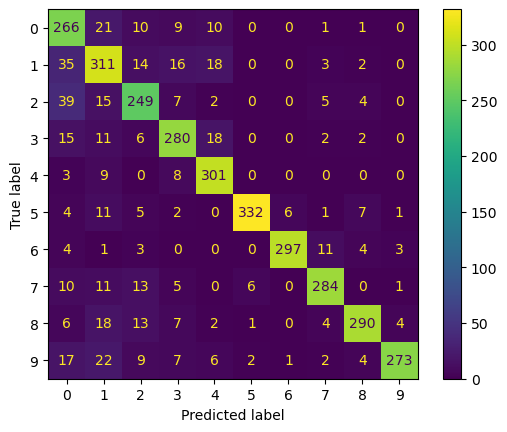

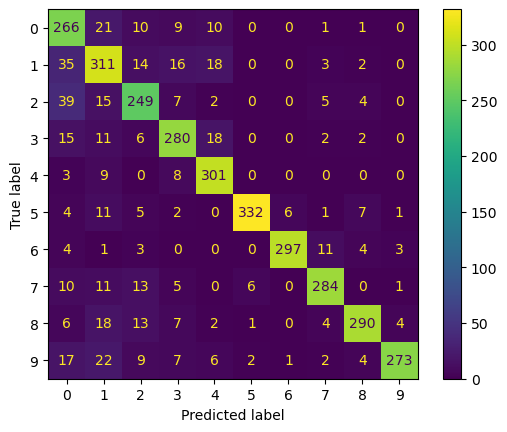

In [66]:
knn_model = KNeighborsClassifier(n_neighbors=best_n_neighbors, metric=best_metric)
knn_model.fit(X_train, y_train.values.ravel())
y_val_pred = knn_model.predict(X_val)
display_confusion_matrix(y_val, pd.Series(y_val_pred))

In [67]:
results_df.loc['KNN',:] = results_knn_df.loc[0, ['mean_test_accuracy', 'mean_test_f1_macro',
       'mean_test_precision_macro', 'mean_test_recall_macro']].values
results_df

,Accuracy,F1 Macro,Precision Macro,Recall Macro
LDA,0.766405,0.763654,0.767966,0.766395
KNN,0.830615,0.833295,0.841235,0.832003


# Gaussian Naive Bayes

In [68]:
gaussian_nb = GaussianNB()

cross_val_results = pd.DataFrame(cross_validate(gaussian_nb , X_train, y_train, cv = 5, scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'] ))

results_df.loc['Gaussian Naive Bayes',:] = cross_val_results[['test_accuracy', 'test_f1_macro',
       'test_precision_macro', 'test_recall_macro']].mean().values
results_df

,Accuracy,F1 Macro,Precision Macro,Recall Macro
LDA,0.766405,0.763654,0.767966,0.766395
KNN,0.830615,0.833295,0.841235,0.832003
Gaussian Naive Bayes,0.666373,0.654972,0.657161,0.667866


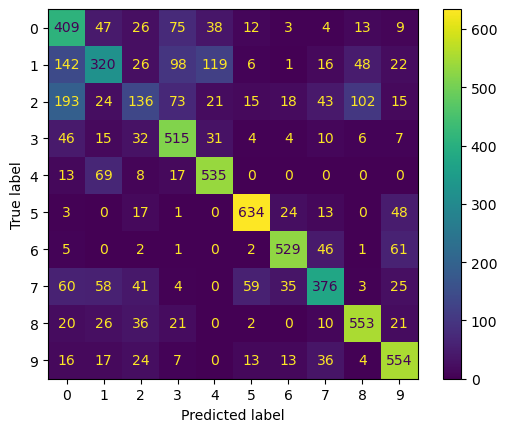

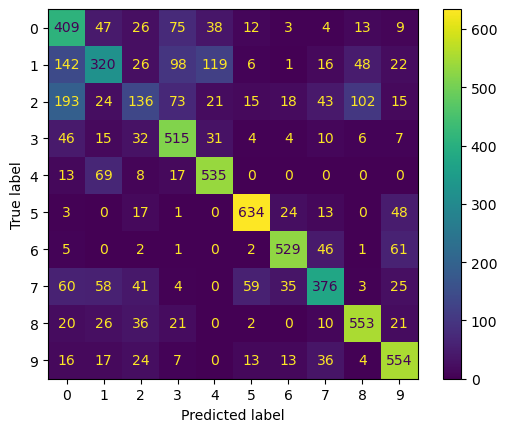

In [69]:
gaussian_nb.fit(X_train, y_train)
display_confusion_matrix(y_train, pd.Series(gaussian_nb.predict(X_train)))

# Logistic Regression

In [70]:
logreg = LogisticRegressionCV(Cs=20, random_state=1, cv=5, scoring = 'f1_macro')

logreg.fit(X_train, y_train)

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",20
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'f1_macro'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multicla

In [71]:
import numpy as np

# convertir valores del dict a array
scores = np.array(list(logreg.scores_.values()))

# media sobre folds y clases
avg_scores = scores.mean(axis=1).mean(axis=0)

# mejor índice
idx = np.argmax(avg_scores)

# mejor C
best_C = logreg.Cs_[idx]

print(f'The best value for C is {best_C}.')

The best value for C is 0.08858667904100823.


In [72]:
logreg = LogisticRegression(C=best_C)
cross_val_results = pd.DataFrame(cross_validate(logreg, X_train, y_train, cv = 5, scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'] ))

results_df.loc['Logistic Regression',:] = cross_val_results[['test_accuracy', 'test_f1_macro',
       'test_precision_macro', 'test_recall_macro']].mean().values

results_df.sort_values(by='Accuracy', ascending=False)

,Accuracy,F1 Macro,Precision Macro,Recall Macro
KNN,0.830615,0.833295,0.841235,0.832003
Logistic Regression,0.797268,0.796528,0.797464,0.797836
LDA,0.766405,0.763654,0.767966,0.766395
Gaussian Naive Bayes,0.666373,0.654972,0.657161,0.667866


# SVM

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

SEED = 42

In [74]:
def plot_decision_boundary(model, model_name, X_train, X_val, y_train, y_val):
    h = 0.02
    x_min, x_max = min(X_train[:, 0].min(), X_val[:, 0].min()) - 1, max(X_train[:, 0].max(), X_val[:, 0].max()) + 1
    y_min, y_max = min(X_train[:, 1].min(), X_val[:, 1].min()) - 1, max(X_train[:, 1].max(), X_val[:, 1].max()) + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    fig, axs = plt.subplots(1, 2, figsize=(6, 3))

    # Scatter plot 1
    axs[0].contourf(xx, yy, Z, alpha=0.6)
    axs[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.Paired)
    axs[0].set_title(f'{model_name}\nTraining accuracy: {accuracy_score(y_train, model.predict(X_train)):.3f}')

    # Scatter plot 2
    axs[1].contourf(xx, yy, Z, alpha=0.6)
    axs[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, edgecolors='k', marker='s', cmap=plt.cm.Paired)
    axs[1].set_title(f'{model_name}\nValidation accuracy: {accuracy_score(y_val, model.predict(X_val)):.3f}')

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show() 

In [75]:
X_train.shape, y_train.shape

((6807, 107), (6807, 1))

## REDUCIR DIMENSIONES

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

pca = PCA(n_components=0.95)

X_train_red = pca.fit_transform(X_train_scaled)
X_val_red = pca.transform(X_val_scaled)

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import numpy as np

C_values = [0.01, 0.1, 1, 10, 100]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

results = []

for C in C_values:
    scores = []

    for train_idx, val_idx in cv.split(X_train_full, y_train_full):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

        model = SVC(kernel='linear', C=C)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        scores.append(f1_score(y_val, y_pred, average='macro'))

    results.append(np.mean(scores))

best_C = C_values[np.argmax(results)]

print("Mejor C:", best_C)


In [77]:
results

[{'C': 0.01, 'gamma': 0.001, 'f1': np.float64(0.020987104922307164)}]

In [89]:
C_values = [0.01, 0.1, 1, 5, 10, 25, 50, 100]
gamma_values = [0.001, 0.005, 0.01, 0.025, 0.05]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

results = []

for C in C_values:
    for gamma in gamma_values:

        scores = []

        for train_idx, val_idx in cv.split(X_train_full, y_train_full):

            X_tr = X_train_full.iloc[train_idx]
            X_val = X_train_full.iloc[val_idx]
            y_tr = y_train_full.iloc[train_idx]
            y_val = y_train_full.iloc[val_idx]

            model = SVC(kernel='rbf', C=C, gamma=gamma)
            model.fit(X_tr, y_tr)

            y_pred = model.predict(X_val)

            scores.append(f1_score(y_val, y_pred, average='macro'))

        results.append({
            "C": C,
            "gamma": gamma,
            "f1": np.mean(scores)
        })

# convertir a array para buscar mejor resultado
best_result = max(results, key=lambda x: x["f1"])

print("Mejor C:", best_result["C"])
print("Mejor gamma:", best_result["gamma"])
print("Mejor F1:", best_result["f1"])

Mejor C: 10
Mejor gamma: 0.01
Mejor F1: 0.9234395321473162


In [90]:
results

[{'C': 0.01, 'gamma': 0.001, 'f1': np.float64(0.24145594571564405)},
 {'C': 0.01, 'gamma': 0.005, 'f1': np.float64(0.5118057622875053)},
 {'C': 0.01, 'gamma': 0.01, 'f1': np.float64(0.675692818096203)},
 {'C': 0.01, 'gamma': 0.025, 'f1': np.float64(0.6487778633875474)},
 {'C': 0.01, 'gamma': 0.05, 'f1': np.float64(0.374662810248439)},
 {'C': 0.1, 'gamma': 0.001, 'f1': np.float64(0.6769971135054441)},
 {'C': 0.1, 'gamma': 0.005, 'f1': np.float64(0.7636821971951816)},
 {'C': 0.1, 'gamma': 0.01, 'f1': np.float64(0.7934771288495911)},
 {'C': 0.1, 'gamma': 0.025, 'f1': np.float64(0.7929858167806728)},
 {'C': 0.1, 'gamma': 0.05, 'f1': np.float64(0.6977458190815018)},
 {'C': 1, 'gamma': 0.001, 'f1': np.float64(0.7907315805754176)},
 {'C': 1, 'gamma': 0.005, 'f1': np.float64(0.8706164976535484)},
 {'C': 1, 'gamma': 0.01, 'f1': np.float64(0.8917371445512259)},
 {'C': 1, 'gamma': 0.025, 'f1': np.float64(0.9048309446516889)},
 {'C': 1, 'gamma': 0.05, 'f1': np.float64(0.8747871706223058)},
 {'C': 

In [91]:
C_values = [10, 15, 20, 25, 50]
gamma_values = [0.01,0.0125, 0.025]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

results = []

for C in C_values:
    for gamma in gamma_values:

        scores = []

        for train_idx, val_idx in cv.split(X_train_full, y_train_full):

            X_tr = X_train_full.iloc[train_idx]
            X_val = X_train_full.iloc[val_idx]
            y_tr = y_train_full.iloc[train_idx]
            y_val = y_train_full.iloc[val_idx]

            model = SVC(kernel='rbf', C=C, gamma=gamma)
            model.fit(X_tr, y_tr)

            y_pred = model.predict(X_val)

            scores.append(f1_score(y_val, y_pred, average='macro'))

        results.append({
            "C": C,
            "gamma": gamma,
            "f1": np.mean(scores)
        })

# convertir a array para buscar mejor resultado
best_result = max(results, key=lambda x: x["f1"])

print("Mejor C:", best_result["C"])
print("Mejor gamma:", best_result["gamma"])
print("Mejor F1:", best_result["f1"])

Mejor C: 15
Mejor gamma: 0.0125
Mejor F1: 0.9255670672159081


In [87]:
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.05]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

results = []

for C in C_values:
    for gamma in gamma_values:

        scores = []

        for train_idx, val_idx in cv.split(X_train_full, y_train_full):

            X_tr = X_train_full.iloc[train_idx]
            X_val = X_train_full.iloc[val_idx]
            y_tr = y_train_full.iloc[train_idx]
            y_val = y_train_full.iloc[val_idx]

            model = SVC(kernel='poly', C=C, gamma=gamma)
            model.fit(X_tr, y_tr)

            y_pred = model.predict(X_val)

            scores.append(f1_score(y_val, y_pred, average='macro'))

        results.append({
            "C": C,
            "gamma": gamma,
            "f1": np.mean(scores)
        })

# convertir a array para buscar mejor resultado
best_result = max(results, key=lambda x: x["f1"])

print("Mejor C:", best_result["C"])
print("Mejor gamma:", best_result["gamma"])
print("Mejor F1:", best_result["f1"])

Mejor C: 10
Mejor gamma: 0.05
Mejor F1: 0.8777678542180676


In [88]:
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.05]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

results = []

for C in C_values:
    for gamma in gamma_values:

        scores = []

        for train_idx, val_idx in cv.split(X_train_full, y_train_full):

            X_tr = X_train_full.iloc[train_idx]
            X_val = X_train_full.iloc[val_idx]
            y_tr = y_train_full.iloc[train_idx]
            y_val = y_train_full.iloc[val_idx]

            model = SVC(kernel='sigmoid', C=C, gamma=gamma)
            model.fit(X_tr, y_tr)

            y_pred = model.predict(X_val)

            scores.append(f1_score(y_val, y_pred, average='macro'))

        results.append({
            "C": C,
            "gamma": gamma,
            "f1": np.mean(scores)
        })

# convertir a array para buscar mejor resultado
best_result = max(results, key=lambda x: x["f1"])

print("Mejor C:", best_result["C"])
print("Mejor gamma:", best_result["gamma"])
print("Mejor F1:", best_result["f1"])

Mejor C: 100
Mejor gamma: 0.001
Mejor F1: 0.8127964985163997


In [78]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in cv.split(X_train_full, y_train_full):

    X_tr = X_train_full.iloc[train_idx]
    X_val = X_train_full.iloc[val_idx]
    y_tr = y_train_full.iloc[train_idx]
    y_val = y_train_full.iloc[val_idx]

    model = SVC(
        kernel='rbf',
        C=10,
        gamma=0.01,
    )

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    scores.append(f1_score(y_val, y_pred, average='macro'))

print("F1 medio:", np.mean(scores))

F1 medio: 0.9234395321473162


In [85]:
results

[{'C': 0.01, 'gamma': 0.001, 'f1': np.float64(0.020987104922307164)}]

In [96]:
best_C = 15
best_gamma = 0.0125
model = SVC(kernel='rbf', C=best_C, gamma= best_gamma)  
model.fit(X_train_full, y_train_full)
y_test_pred = model.predict(X_test)

In [97]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1 macro:", f1_score(y_test, y_test_pred, average='macro'))
print(classification_report(y_test, y_test_pred))

Accuracy: 0.9328937160589604
F1 macro: 0.9324617739118686
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       234
           1       0.86      0.88      0.87       284
           2       0.93      0.89      0.91       260
           3       0.90      0.90      0.90       228
           4       0.98      0.97      0.97       267
           5       0.97      0.98      0.97       282
           6       0.96      0.99      0.97       252
           7       0.96      0.93      0.94       278
           8       0.96      0.94      0.95       264
           9       0.93      0.97      0.95       229

    accuracy                           0.93      2578
   macro avg       0.93      0.93      0.93      2578
weighted avg       0.93      0.93      0.93      2578



# HACER SUBMISSIONS

In [98]:
import pandas as pd

def create_submission(model, X_test, output_path="submission.csv"):
    """
    Genera un archivo CSV de submission con formato:
    ID, POSITION

    Parameters:
    - model: modelo ya entrenado (con fit hecho)
    - X_test: features del test (mismo preprocesado que train)
    - output_path: nombre del archivo de salida
    """

    # Predicción
    y_pred = model.predict(X_test)

    # Crear DataFrame con el formato requerido
    submission = pd.DataFrame({
        "ID": range(len(y_pred)),
        "POSITION": y_pred.astype(int)
    })

    # Guardar CSV sin índice
    submission.to_csv(output_path, index=False)

    print(f"Submission guardada en: {output_path}")
    print(submission.head())

    return submission

In [99]:
X_test = pd.read_csv('../data/processed/test_nolabels_mar_proc.csv')
output_path = "../data/submissions/submission_svm_rbf_mar.csv"
create_submission(model, X_test, output_path)

Submission guardada en: ../data/submissions/submission_svm_rbf_mar.csv
   ID  POSITION
0   0         5
1   1         6
2   2         9
3   3         1
4   4         0


,ID,POSITION
0,0,5
1,1,6
2,2,9
3,3,1
4,4,0
...,...,...
3218,3218,0
3219,3219,4
3220,3220,2
3221,3221,3
